In [1]:
import pandas as pd
import matplotlib as plt
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn import svm
from sklearn.tree import DecisionTreeClassifier
import warnings
warnings.filterwarnings('ignore')

In [4]:
users = pd.read_csv('users.csv')

In [5]:
users.head()

,id,password,last_login,is_superuser,last_name,is_staff,is_active,date_joined,created_at,updated_at,phone,role,image,address,is_verified,is_deleted,deleted_at,company_id
0,3,pbkdf2_sha256$390000$9zUHsyJI3Z9PAEpyDp96r0$za...,NaN,f,Tatar,f,t,2023-03-25 23:19:01+01,2023-03-25 23:19:01.881+01,2023-04-29 20:16:16.227+01,12345678,admin,NaN,NaN,t,f,NaN,1
1,4,pbkdf2_sha256$320000$RTonQinRE9ArRJOWgaBotT$t4...,NaN,f,Triki,f,t,2023-03-25 23:19:56+01,2023-03-25 23:19:57.144+01,2023-04-29 20:15:04.169+01,12345678,admin,NaN,NaN,t,f,NaN,1
2,5,pbkdf2_sha256$320000$WcjArypPQ4Zr8ox4gpv4E8$j9...,NaN,f,Mejdoub,f,t,2023-03-25 23:29:00+01,2023-03-25 23:29:01.121+01,2023-04-29 20:15:14.682+01,12345678,admin,NaN,NaN,t,f,NaN,1
3,7,pbkdf2_sha256$320000$AemxwVyTpykMWcQWO0Z0Nf$Qv...,NaN,f,mejdoub,f,t,2023-03-27 14:28:35.697+01,2023-03-27 14:28:35.969+01,2023-03-27 14:28:36.005+01,27789553,cashier,NaN,NaN,t,f,NaN,1
4,9,pbkdf2_sha256$390000$VfKU0LIHMbfoYcl7Dgk7NX$Vc...,NaN,f,riahi,f,t,2023-03-27 20:53:51.34+01,2023-03-27 20:53:51.62+01,2023-03-27 20:53:51.649+01,29031200,cashier,NaN,NaN,t,f,NaN,1


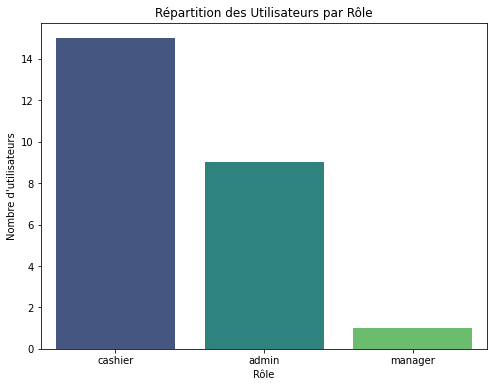

In [7]:
# Compter le nombre d'admins, de managers et de cashiers
role_counts = users['role'].value_counts()

# Créer un graphique à barres pour représenter les résultats
plt.figure(figsize=(8, 6))
sns.barplot(x=role_counts.index, y=role_counts.values, palette='viridis')
plt.xlabel('Rôle')
plt.ylabel('Nombre d\'utilisateurs')
plt.title('Répartition des Utilisateurs par Rôle')
plt.show()

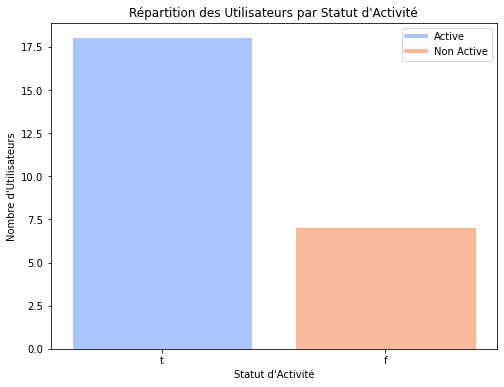

In [11]:
# Compter le nombre d'utilisateurs connectés et déconnectés
active_counts = users['is_active'].value_counts()

# Créer un graphique à barres pour représenter les résultats
plt.figure(figsize=(8, 6))
colors = sns.color_palette('coolwarm', len(active_counts))
bars = sns.barplot(x=active_counts.index, y=active_counts.values, palette=colors)

# Ajouter une légende
legend_labels = ['Active', 'Non Active']
for i, color in enumerate(colors):
    bars.get_children()[i].set_color(color)

plt.legend(handles=[plt.Line2D([0], [0], color=color, lw=4) for color in colors], labels=legend_labels)

plt.xlabel('Statut d\'Activité')
plt.ylabel('Nombre d\'Utilisateurs')
plt.title('Répartition des Utilisateurs par Statut d\'Activité')
plt.show()